# Gemini 3.1 Reproducibility / Inter-run Consistency

5 runs per direction (original + `_RETRY1..4`) on the full-example Nemeth sets.

Goal: *are the same examples failing across runs, or are failures scattered?*

In [32]:
from pathlib import Path
from typing import Literal
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from analysis_utils import parse_result_file

RESULTS_DIR = Path('../results/gemini')
N_RUNS = 5
Direction = Literal['to-nemeth', 'from-nemeth']
DIRECTIONS: list[Direction] = ['to-nemeth', 'from-nemeth']

def run_path_by_try_number(direction: Direction, retry: int) -> Path:
    # return a path like "from-nemeth-gemini-3.1-pro-preview-2471exs-0-200tests_RETRY2.txt" etc.
    base = f'{direction}-gemini-3.1-pro-preview-2471exs-0-200tests'
    suffix = '' if retry == 0 else f'_RETRY{retry}'
    return RESULTS_DIR / f'{base}{suffix}.txt'

## 1. Load all runs into a per-example DataFrame

In [33]:
def load_direction(direction: Direction) -> pd.DataFrame:
    runs = [parse_result_file(str(run_path_by_try_number(direction, i))) for i in range(N_RUNS)]
    lengths = {len(r) for r in runs}
    assert len(lengths) == 1, f'run length mismatch for {direction}: {lengths}'
    df = pd.DataFrame({
        'input': [r.input_text for r in runs[0]],
        'expected': [r.expected for r in runs[0]],
    })
    for i, run in enumerate(runs):
        df[f'is_correct_{i}'] = [r.is_correct for r in run]
        df[f'computed_{i}'] = [r.computed for r in run]
    df['pass_count'] = df[[f'is_correct_{i}' for i in range(N_RUNS)]].sum(axis=1)
    return df

data = {d: load_direction(d) for d in DIRECTIONS}
{d: len(df) for d, df in data.items()}

{'to-nemeth': 200, 'from-nemeth': 200}

In [34]:
data['to-nemeth'].head()

,input,expected,is_correct_0,computed_0,is_correct_1,computed_1,is_correct_2,computed_2,is_correct_3,computed_3,is_correct_4,computed_4,pass_count
0,"<math xmlns=""http://www.w3.org/1998/Math/MathM...",⠿⠹⠒⠭⠌⠲⠼⠤⠂⠀⠨⠅⠀⠼⠆⠭⠬⠹⠔⠌⠆⠼,True,⠿⠹⠒⠭⠌⠲⠼⠤⠂⠀⠨⠅⠀⠼⠆⠭⠬⠹⠔⠌⠆⠼,False,⠹⠒⠭⠌⠲⠼⠤⠂⠀⠨⠅⠀⠆⠭⠬⠹⠔⠌⠆⠼,True,⠿⠹⠒⠭⠌⠲⠼⠤⠂⠀⠨⠅⠀⠼⠆⠭⠬⠹⠔⠌⠆⠼,True,⠿⠹⠒⠭⠌⠲⠼⠤⠂⠀⠨⠅⠀⠼⠆⠭⠬⠹⠔⠌⠆⠼,False,⠹⠒⠭⠌⠲⠼⠤⠂⠀⠨⠅⠀⠼⠆⠭⠬⠹⠔⠌⠆⠼,3
1,<math><mrow><mi>a</mi><mo>=</mo><mover accent=...,⠁⠀⠨⠅⠀⠽⠱⠤⠃⠭⠱,True,⠁⠀⠨⠅⠀⠽⠱⠤⠃⠭⠱,True,⠁⠀⠨⠅⠀⠽⠱⠤⠃⠭⠱,True,⠁⠀⠨⠅⠀⠽⠱⠤⠃⠭⠱,True,⠁⠀⠨⠅⠀⠽⠱⠤⠃⠭⠱,True,⠁⠀⠨⠅⠀⠽⠱⠤⠃⠭⠱,5
2,<math><mi>c</mi></math>,⠰⠉,True,⠰⠉,True,⠰⠉,True,⠰⠉,True,⠰⠉,True,⠰⠉,5
3,"<math xmlns=""http://www.w3.org/1998/Math/MathM...",⠼⠂⠴⠴,True,⠼⠂⠴⠴,True,⠼⠂⠴⠴,True,⠼⠂⠴⠴,True,⠼⠂⠴⠴,True,⠼⠂⠴⠴,5
4,<math><mrow><msup><mtext>(e</mtext><mn>3</mn><...,⠷⠑⠘⠒⠠⠀⠼⠒⠾⠠,False,⠷⠑⠘⠒⠐⠠⠀⠒⠾⠠,False,⠷⠑⠘⠒⠠⠀⠒⠾⠠,False,⠷⠑⠘⠒⠠⠀⠒⠾⠠,False,⠷⠑⠘⠒⠐⠠⠀⠒⠾⠠,True,⠷⠑⠘⠒⠠⠀⠼⠒⠾⠠,1


In [35]:
data['from-nemeth'].head()

,input,expected,is_correct_0,computed_0,is_correct_1,computed_1,is_correct_2,computed_2,is_correct_3,computed_3,is_correct_4,computed_4,pass_count
0,⠿⠹⠒⠭⠌⠲⠼⠤⠂⠀⠨⠅⠀⠼⠆⠭⠬⠹⠔⠌⠆⠼,"<math xmlns=""http://www.w3.org/1998/Math/MathM...",True,"<math xmlns=""http://www.w3.org/1998/Math/MathM...",True,"<math xmlns=""http://www.w3.org/1998/Math/MathM...",True,<math><mrow><mtext>&#xA0;</mtext><mtext>&#xA0;...,True,"<math xmlns=""http://www.w3.org/1998/Math/MathM...",True,"<math xmlns=""http://www.w3.org/1998/Math/MathM...",5
1,⠁⠀⠨⠅⠀⠽⠱⠤⠃⠭⠱,<math><mrow><mi>a</mi><mo>=</mo><mover accent=...,True,<math><mrow><mi>a</mi><mo>=</mo><mover accent=...,True,<math><mrow><mi>a</mi><mo>=</mo><mover accent=...,True,<math><mrow><mi>a</mi><mo>=</mo><mover accent=...,True,<math><mrow><mi>a</mi><mo>=</mo><mover accent=...,True,<math><mrow><mi>a</mi><mo>=</mo><mover accent=...,5
2,⠰⠉,<math><mi>c</mi></math>,True,<math><mi>c</mi></math>,True,<math><mi>c</mi></math>,True,<math><mi>c</mi></math>,True,<math><mi>c</mi></math>,True,<math><mi>c</mi></math>,5
3,⠼⠂⠴⠴,"<math xmlns=""http://www.w3.org/1998/Math/MathM...",True,<math><mn>100</mn></math>,True,<math><mn>100</mn></math>,True,<math><mn>100</mn></math>,True,<math><mn>100</mn></math>,True,"<math xmlns=""http://www.w3.org/1998/Math/MathM...",5
4,⠷⠑⠘⠒⠠⠀⠼⠒⠾⠠,<math><mrow><msup><mtext>(e</mtext><mn>3</mn><...,False,"<math><mrow><mo stretchy=""false"">(</mo><msup><...",False,"<math><mrow><mo stretchy=""false"">(</mo><msup><...",False,<math><mrow><mo>(</mo><msup><mi>e</mi><mn>3</m...,False,"<math><mrow><mo stretchy=""false"">(</mo><msup><...",False,"<math><mrow><mo stretchy=""false"">(</mo><msup><...",0


## 2. per-run accuracy

In [36]:
rows = []
for d, df in data.items():
    per_run = [df[f'is_correct_{i}'].sum() for i in range(N_RUNS)]
    rows.append({
        'direction': d,
        'n': len(df),
        **{f'run{i}': v for i, v in enumerate(per_run)},
        'mean': np.mean(per_run),
        'std': np.std(per_run, ddof=1),
    })
agg = pd.DataFrame(rows)
agg

,direction,n,run0,run1,run2,run3,run4,mean,std
0,to-nemeth,200,183,177,182,180,184,181.2,2.774887
1,from-nemeth,200,183,184,179,184,182,182.4,2.073644


## 3. Per-example consistency

`pass_count` histogram: a deterministic model would be bimodal at 0 and 5. Mass at 1–4 = flaky examples.

In [37]:
def pass_count_dist(df: pd.DataFrame) -> pd.Series:
    return df['pass_count'].value_counts().reindex(range(N_RUNS + 1), fill_value=0).sort_index()

dist = pd.DataFrame({d: pass_count_dist(df) for d, df in data.items()})
dist.index.name = 'pass_count'
dist

,to-nemeth,from-nemeth
pass_count,,
0,14,9
1,2,6
2,0,3
3,5,2
4,6,6
5,173,174


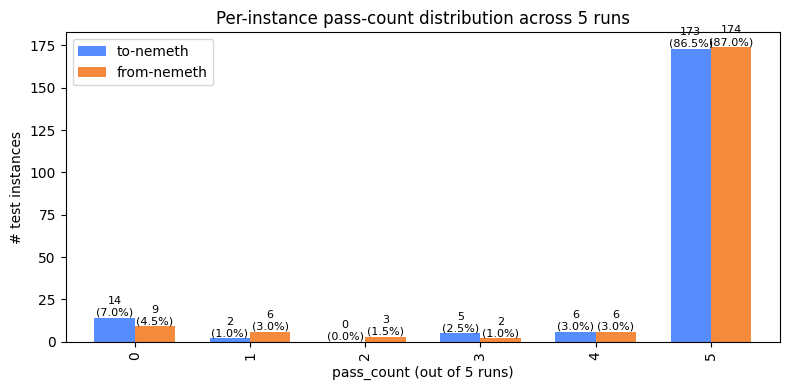

In [38]:
fig, ax = plt.subplots(figsize=(8, 4))
dist.plot.bar(ax=ax, width=0.7)
ax.set_xlabel('pass_count (out of 5 runs)')
ax.set_ylabel('# test instances')
ax.set_title('Per-instance pass-count distribution across 5 runs')
totals = dist.sum(axis=0)
for container, direction in zip(ax.containers, dist.columns):
    total = totals[direction]
    labels = [f'{v}\n({v / total:.1%})' for v in dist[direction]]
    ax.bar_label(container, labels=labels, fontsize=8)
plt.tight_layout()
plt.show()